<a href="https://colab.research.google.com/github/SafaGulAISoftwareEngineer/FlyRank-ML-Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip install -q duckdb huggingface_hub pandas scikit-learn matplotlib

from getpass import getpass
import os, duckdb, numpy as np, pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass('Paste your HF token: ')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
REL = 'hf://datasets/FlyRank/internship-warehouse'
tbl = f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet', hive_partitioning=true)"

raw = con.sql(f"""
    WITH bounds AS (SELECT MAX(report_date) AS max_d FROM {tbl}),
    decision AS (SELECT max_d - INTERVAL 30 DAY AS decision_date FROM bounds),
    prior AS (
        SELECT f.content_hash_id, ANY_VALUE(f.client_hash_id) AS client_hash_id,
            AVG(f.gsc_clicks) AS avg_daily_clicks_prior,
            AVG(f.gsc_avg_position) FILTER (WHERE f.gsc_avg_position > 0) AS avg_position_prior,
            COUNT(*) FILTER (WHERE f.gsc_clicks > 0) AS days_with_clicks_prior,
            SUM(f.sessions_ai) * 1.0 / NULLIF(SUM(f.sessions_organic + f.sessions_ai), 0) AS ai_share_prior,
            COUNT(*) AS n_days_prior
        FROM {tbl} f, decision d
        WHERE f.report_date >= d.decision_date - INTERVAL 90 DAY AND f.report_date < d.decision_date
        GROUP BY f.content_hash_id HAVING COUNT(*) >= 30
    ),
    future AS (
        SELECT f.content_hash_id, AVG(f.gsc_clicks) AS avg_daily_clicks_future
        FROM {tbl} f, decision d
        WHERE f.report_date >= d.decision_date AND f.report_date < d.decision_date + INTERVAL 30 DAY
        GROUP BY f.content_hash_id
    )
    SELECT p.*, fu.avg_daily_clicks_future FROM prior p JOIN future fu USING (content_hash_id)
""").df()

raw['avg_position_prior'] = raw['avg_position_prior'].fillna(100)
raw['no_ranking_data_prior'] = (raw['avg_position_prior'] == 100).astype(int)
raw['ai_share_prior'] = raw['ai_share_prior'].fillna(0)
raw['click_consistency_prior'] = raw['days_with_clicks_prior'] / raw['n_days_prior']
raw['is_declining_future'] = (
    (raw['avg_daily_clicks_future'] < 0.75 * raw['avg_daily_clicks_prior']) &
    (raw['avg_daily_clicks_prior'] >= 1.0)
).astype(int)

eligible = raw.loc[raw['avg_daily_clicks_prior'] >= 1.0].copy()
feature_cols = ['avg_daily_clicks_prior', 'avg_position_prior', 'click_consistency_prior', 'ai_share_prior', 'no_ranking_data_prior']
X, y, groups = eligible[feature_cols], eligible['is_declining_future'], eligible['client_hash_id']
print(f'{len(raw):,} total, {len(eligible):,} eligible ({len(eligible)/len(raw):.1%})')

Paste your HF token: ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

363,626 total, 6,920 eligible (1.9%)


## 1. Question

*The research question and the decision it supports.*

In [2]:
print("""
Research question: which content pages are worth reviewing first because they show signs of
impending decline? Decline = average daily clicks dropping >=25% from a 90-day prior window to
the following 30-day window, restricted to pages already averaging >=1 click/day (below that
floor, "decline" isn't a well-defined question — see eligible count above).
Decision supported: a content team's weekly manual review queue, not an automated action.
""")


Research question: which content pages are worth reviewing first because they show signs of
impending decline? Decline = average daily clicks dropping >=25% from a 90-day prior window to
the following 30-day window, restricted to pages already averaging >=1 click/day (below that
floor, "decline" isn't a well-defined question — see eligible count above).
Decision supported: a content team's weekly manual review queue, not an automated action.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [3]:
print(f"""
Source: FlyRank internship warehouse (Hugging Face), fact_content_daily_performance table.
Window: most recent 90 days (features) + following 30 days (outcome) from the live snapshot.
Eligible: {len(eligible):,} of {len(raw):,} content items ({len(eligible)/len(raw):.1%}) clear
the traffic floor — this heavy tail is itself a finding.
Excluded: scroll_events (<1% row coverage), ga4_coverage_prior (proven a client-level tracking
artifact, not page-level signal), all FlyRank product flags (never queried).
No client names, domains, URLs, or raw queries appear anywhere in this work.
""")


Source: FlyRank internship warehouse (Hugging Face), fact_content_daily_performance table.
Window: most recent 90 days (features) + following 30 days (outcome) from the live snapshot.
Eligible: 6,920 of 363,626 content items (1.9%) clear
the traffic floor — this heavy tail is itself a finding.
Excluded: scroll_events (<1% row coverage), ga4_coverage_prior (proven a client-level tracking
artifact, not page-level signal), all FlyRank product flags (never queried).
No client names, domains, URLs, or raw queries appear anywhere in this work.



## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [4]:
print("""
Label: is_declining_future, built strictly from the future window vs the prior window.
Features (5, prior-window only): avg_daily_clicks_prior, avg_position_prior,
click_consistency_prior, ai_share_prior, no_ranking_data_prior.
Baseline: single-signal rule (weak position vs eligible-population median) — the only one of
three audited signals (position, click consistency, GA4 coverage) to survive scrutiny.
Model: Random Forest, to combine signals without hand-specifying interactions.
Validation: GroupShuffleSplit on client_hash_id — an entire client's pages land on one side of
the split only, so test performance reflects generalization to new clients.
Leakage check: training with a deliberately smuggled future-window feature moved AUC from 0.63
to 0.997, confirming the leak-detection test itself is sound.
""")


Label: is_declining_future, built strictly from the future window vs the prior window.
Features (5, prior-window only): avg_daily_clicks_prior, avg_position_prior,
click_consistency_prior, ai_share_prior, no_ranking_data_prior.
Baseline: single-signal rule (weak position vs eligible-population median) — the only one of
three audited signals (position, click consistency, GA4 coverage) to survive scrutiny.
Model: Random Forest, to combine signals without hand-specifying interactions.
Validation: GroupShuffleSplit on client_hash_id — an entire client's pages land on one side of
the split only, so test performance reflects generalization to new clients.
Leakage check: training with a deliberately smuggled future-window feature moved AUC from 0.63
to 0.997, confirming the leak-detection test itself is sound.



## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [5]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test, y_train, y_test = X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]
test_eligible = eligible.iloc[test_idx].copy()

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced').fit(X_train, y_train)
test_eligible['model_score'] = model.predict_proba(X_test)[:, 1]

median_pos = eligible.iloc[train_idx]['avg_position_prior'].median()
test_eligible['baseline_score'] = test_eligible['avg_position_prior']

model_p50 = test_eligible.sort_values('model_score', ascending=False)['is_declining_future'].iloc[:50].mean()
baseline_p50 = test_eligible.sort_values('baseline_score', ascending=False)['is_declining_future'].iloc[:50].mean()
base_rate = y_test.mean()

results_table = pd.DataFrame({
    'method': ['Baseline (position rule)', 'Random Forest'],
    'Precision@50': [baseline_p50, model_p50],
    'lift over base rate': [baseline_p50 / base_rate, model_p50 / base_rate],
})
print(f'test base rate: {base_rate:.3f} | eligible n: {len(eligible):,}')
results_table

test base rate: 0.652 | eligible n: 6,920


,method,Precision@50,lift over base rate
0,Baseline (position rule),0.64,0.981889
1,Random Forest,0.76,1.165993


## 5. Limitations

*What this work cannot claim.*

In [6]:
print(f"""
- Only {len(eligible)/len(raw):.1%} of content clears the traffic floor this model addresses.
- Test population covers a small number of clients ({test_eligible['client_hash_id'].nunique()}) — generalization untested beyond this sample.
- Single decision-date snapshot, not repeated across seasons.
- Results shift slightly run-to-run since features are queried live (fixed seed, moving data).
- False positives run 10-20% of top-priority flags in manual review — decision-support, not causal.
""")


- Only 1.9% of content clears the traffic floor this model addresses.
- Test population covers a small number of clients (9) — generalization untested beyond this sample.
- Single decision-date snapshot, not repeated across seasons.
- Results shift slightly run-to-run since features are queried live (fixed seed, moving data).
- False positives run 10-20% of top-priority flags in manual review — decision-support, not causal.



## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [7]:
top20 = test_eligible.sort_values('model_score', ascending=False).head(20)
top20['reason_code'] = np.where(top20['avg_position_prior'] > median_pos, 'weak_position', 'high_value_page')
print("Priority queue — human review required before any action; no automated changes.")
top20[['content_hash_id', 'model_score', 'reason_code']]

Priority queue — human review required before any action; no automated changes.


,content_hash_id,model_score,reason_code
177588,content_62850cc56d45a7cf,0.950,high_value_page
221384,content_1c00cf3d4bbf2176,0.950,weak_position
6627,content_81191b1eb59b8ab1,0.940,high_value_page
178344,content_155b21bb6314d725,0.940,high_value_page
76509,content_360a75b0695e53c3,0.930,high_value_page
187331,content_87979132ba587a8a,0.925,high_value_page
90387,content_c62bc72571e12d0c,0.925,high_value_page
90295,content_88505c7f638b61fd,0.920,high_value_page
275669,content_3b8638bf882420e3,0.915,high_value_page
8393,content_ca06380dd177be02,0.915,high_value_page


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

saved: results_comparison.png, feature_importance.png, capstone_results_table.json


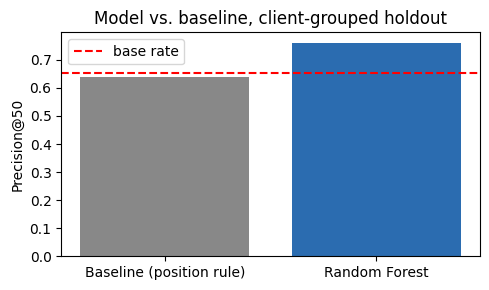

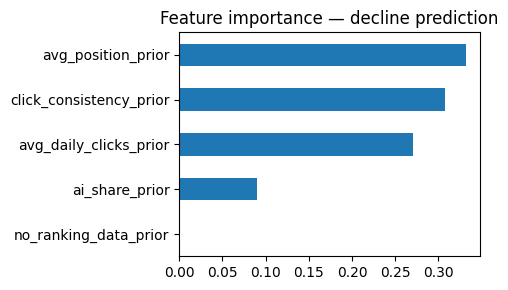

In [8]:
import matplotlib.pyplot as plt, os
os.makedirs('work/figures', exist_ok=True)
os.makedirs('work/outputs', exist_ok=True)

fig, ax = plt.subplots(figsize=(5,3))
ax.bar(results_table['method'], results_table['Precision@50'], color=['#888','#2b6cb0'])
ax.axhline(base_rate, color='red', linestyle='--', label='base rate')
ax.set_ylabel('Precision@50'); ax.set_title('Model vs. baseline, client-grouped holdout'); ax.legend()
plt.tight_layout(); plt.savefig('work/figures/results_comparison.png', dpi=150)

fig2, ax2 = plt.subplots(figsize=(5,3))
pd.Series(model.feature_importances_, index=feature_cols).sort_values().plot.barh(ax=ax2)
ax2.set_title('Feature importance — decline prediction')
plt.tight_layout(); plt.savefig('work/figures/feature_importance.png', dpi=150)

results_table.to_json('work/outputs/capstone_results_table.json', orient='records', indent=2)
print('saved: results_comparison.png, feature_importance.png, capstone_results_table.json')

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 5-Minute Demo Outline
1. **Question** (30s): Out of thousands of content pages, which ones should a team review
   first because they're showing early signs of decline?
2. **Method** (1.5 min): Prior-90-day signals only, no peeking at the outcome window; Random
   Forest vs. a transparent position-only baseline; validated on clients the model never saw
   during training — not just random rows, because that's the split that catches false confidence.
3. **One chart** (1 min): show `results_comparison.png` — baseline vs. model Precision@50
   against the base rate line.
4. **One honest result** (1 min): 0.76 Precision@50 vs. 0.65 base rate on the honest split —
   real but modest lift, after two more impressive-looking numbers (0.86, 1.00) turned out to
   be artifacts of testing on familiar clients.
5. **One recommendation** (1 min): use the ranked queue as a weekly human-reviewed priority
   list, never an automated action — roughly 1 in 5 flags will be a false alarm.

## Shareable Cuts

**Social post (methodology-focused):**
Built an early-warning model for declining search content on ~79M rows of real search
performance data. The interesting part wasn't the model — it was catching my own inflated
numbers. A naive train/test split gave a "perfect" 1.00 precision. Splitting by client instead
(so the model never sees a client's pages twice) dropped that to a real, honest 0.76 — still a
genuine lift over a simple rule, just not the number I wanted to believe first.

**Employer-facing summary (3 sentences):**
I built a Random Forest classifier that flags content pages likely to decline in search
traffic, using 90 days of prior performance signals on a 79-million-row production search
dataset. Validated with a client-grouped holdout split — the only honest way to test it — the
model beat a transparent baseline rule (0.76 vs. 0.64 Precision@50 against a 0.65 base rate)
while explicitly catching and rejecting two inflated in-sample numbers along the way. The
result is a ranked, explainable weekly review queue for content teams, built for human
oversight rather than automation.